In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/deliveries.csv')
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}

df['bowling_team'] = df['bowling_team'].replace(team_name_map)
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [2]:
df.fillna(0, inplace=True)

df = df[df['inning'].isin([1, 2])]

In [3]:
print(df.columns.tolist())


['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [4]:
match_extras = df.groupby(['match_id', 'bowling_team', 'inning'])['extra_runs'].sum().reset_index()

team_extras = match_extras.groupby(['bowling_team', 'inning'])['extra_runs'].mean().reset_index()

team_extras.rename(columns={'extra_runs': 'avg_extras_per_match'}, inplace=True)

display(team_extras.head())

,bowling_team,inning,avg_extras_per_match
0,Chennai Super Kings,1,7.722222
1,Chennai Super Kings,2,7.753846
2,Deccan Chargers,1,9.187500
3,Deccan Chargers,2,8.488372
4,Delhi Capitals,1,8.194245


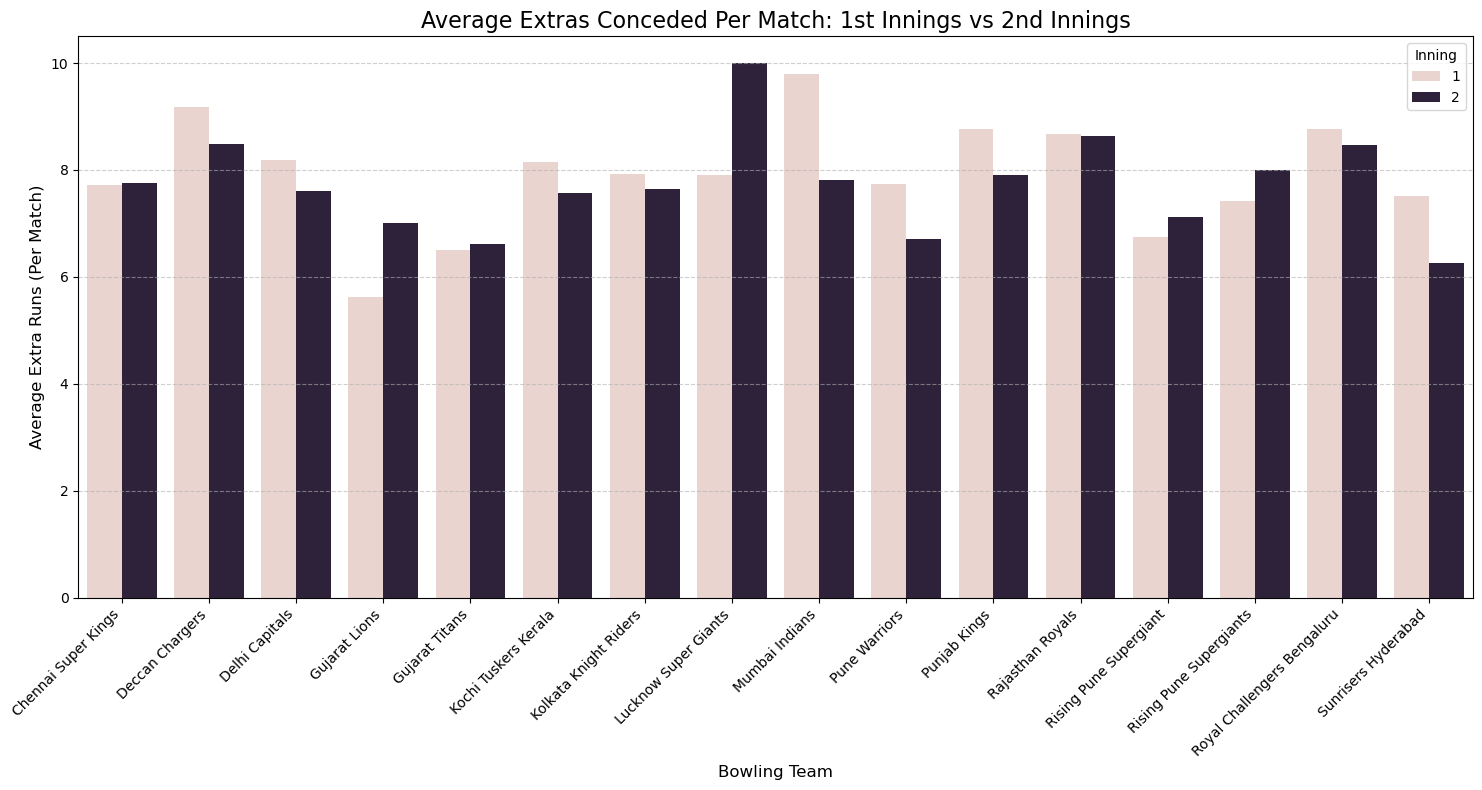

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.barplot(data=team_extras, x='bowling_team', y='avg_extras_per_match', hue='inning')

plt.title('Average Extras Conceded Per Match: 1st Innings vs 2nd Innings', fontsize=16)
plt.xlabel('Bowling Team', fontsize=12)
plt.ylabel('Average Extra Runs (Per Match)', fontsize=12)


plt.xticks(rotation=45, ha='right')
plt.legend(title='Inning')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [9]:
type_breakdown = df[df['extra_runs'] > 0].groupby(['bowling_team', 'extras_type']).size().unstack(fill_value=0)
type_breakdown.head()

extras_type,byes,legbyes,noballs,penalty,wides
bowling_team,,,,,
Chennai Super Kings,60,421,97,0,946
Deccan Chargers,31,166,49,1,280
Delhi Capitals,24,143,47,0,387
Delhi Daredevils,39,324,86,0,550
Gujarat Lions,7,55,7,0,91
